In [1]:
#  Imports & Mount ───────────────────────────────────
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

BASE = "/content/drive/MyDrive/nlp/final project/"

Mounted at /content/drive


In [2]:
# Load all saved files
# 1. Full dataset with sentiment (196K articles)
df = pd.read_csv(BASE + "articles_with_sentiment.csv")
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(f"df (sentiment): {df.shape}")

# 2. NER results (25K sample with orgs, tech_terms, topic_id, industry)
df_ner = pd.read_csv(BASE + "df_model_bertopic_topics_org_tech.csv")
print(f"df_ner: {df_ner.shape}")

# 3. BERTopic table (topic_id -> top_words)
bertopic_table = pd.read_csv(BASE + "bertopic_table_sample.csv")
print(f"bertopic_table: {bertopic_table.shape}")

print("\ndf columns:", df.columns.tolist())
print("df_ner columns:", df_ner.columns.tolist())
print("bertopic_table columns:", bertopic_table.columns.tolist())

df (sentiment): (196276, 12)
df_ner: (25000, 12)
bertopic_table: (161, 3)

df columns: ['url', 'date', 'title', 'clean_text', 'text_len', 'domain', 'inference_text', 'sentiment', 'neg_score', 'neu_score', 'pos_score', 'sentiment_compound']
df_ner columns: ['url', 'date', 'title', 'clean_text', 'text_len', 'domain', 'text_bt', 'topic_id', 'ner_text', 'orgs_raw', 'orgs', 'tech_terms']
bertopic_table columns: ['topic_id', 'count', 'top_words']


In [3]:
#  CELL 3: Parse list columns in df_ner
def parse_list_col(val):
    if isinstance(val, list): return val
    if pd.isna(val) or str(val) in ("", "[]", "nan"): return []
    try: return ast.literal_eval(val)
    except: return []

df_ner["orgs"]       = df_ner["orgs"].apply(parse_list_col)
df_ner["tech_terms"] = df_ner["tech_terms"].apply(parse_list_col)

In [4]:
# CELL 4: Map topic_id -> industry (same rules as before)
INDUSTRY_RULES = [
    ("Enterprise IT & Digital Transformation", [
        "enterprise", "software", "saas", "cloud", "infrastructure", "deployment"
    ]),
    ("Generative AI & Creative Tools", [
        "image", "photo", "art", "midjourney", "diffusion", "adobe"
    ]),
    ("AI Chips & Financial Markets", [
        "chip", "gpu", "semiconductor", "nvidia", "amd", "intel", "nasdaq"
    ]),
    ("Healthcare & Clinical AI", [
        "clinical", "patient", "medical", "health", "hospital", "drug", "disease"
    ]),
    ("Finance & Investment", [
        "stock", "market", "trading", "investor", "fund", "earnings"
    ]),
    ("ChatGPT & AI Assistants", [
        "chatgpt", "gpt", "chatbot", "assistant", "copilot"
    ]),
    ("OpenAI & Big Tech", [
        "openai", "microsoft", "google", "meta", "anthropic", "gemini"
    ]),
    ("Cybersecurity & AI Risk", [
        "security", "risk", "threat", "breach", "malware"
    ]),
]

def map_topic_to_industry(top_words):
    tw = str(top_words).lower()
    best_label, best_hits = "Other / Mixed", 0
    for label, keywords in INDUSTRY_RULES:
        hits = sum(1 for kw in keywords if kw in tw)
        if hits > best_hits:
            best_hits, best_label = hits, label
    return best_label

bertopic_table["industry"] = bertopic_table["top_words"].apply(map_topic_to_industry)
topic_to_industry = dict(zip(bertopic_table["topic_id"].astype(int), bertopic_table["industry"]))

df_ner["industry"] = df_ner["topic_id"].map(topic_to_industry)
df_ner.loc[df_ner["topic_id"] == -1, "industry"] = "Outlier / Unclustered"
df_ner["industry"] = df_ner["industry"].fillna("Other / Mixed")

print(df_ner["industry"].value_counts())

# CELL 5: Merge sentiment onto NER dataframe
df_merged = df_ner.merge(
    df[["url", "sentiment", "sentiment_compound", "neg_score", "neu_score", "pos_score", "date"]],
    on="url",
    how="left"
)

print(f"Merged shape: {df_merged.shape}")
print(f"Rows with sentiment: {df_merged['sentiment'].notna().sum()}")
display(df_merged[["url", "industry", "orgs", "tech_terms", "sentiment", "sentiment_compound"]].head())

df_merged.to_csv(BASE + "articles_merged_full.csv", index=False)
print("Saved: articles_merged_full.csv")

industry
Outlier / Unclustered                     9621
Other / Mixed                             8120
Generative AI & Creative Tools            2505
AI Chips & Financial Markets              1425
Healthcare & Clinical AI                   885
OpenAI & Big Tech                          793
ChatGPT & AI Assistants                    622
Enterprise IT & Digital Transformation     450
Finance & Investment                       430
Cybersecurity & AI Risk                    149
Name: count, dtype: int64
Merged shape: (25000, 19)
Rows with sentiment: 25000


,url,industry,orgs,tech_terms,sentiment,sentiment_compound
0,https://www.fox35orlando.com/news/wendys-addin...,Other / Mixed,"[Wendy, LiveNewsWeatherGood Day]",[],neutral,0.000284
1,https://citylife.capetown/ps/uncategorized/has...,AI Chips & Financial Markets,"[ایا چا د AI, کال د دسمبر, ژوندد نوي ټیکنالوژۍ...",[],neutral,0.003190
2,https://timesofindia.indiatimes.com/technology...,OpenAI & Big Tech,[The Times of India],[],neutral,0.000078
3,https://www.lokmattimes.com/entertainment/need...,Other / Mixed,"[AI - www.lokmattimes.comCityMarathi, ViralLokma]",[gpu],neutral,0.003351
4,http://en.people.cn/n3/2022/0920/c90000-101494...,Healthcare & Clinical AI,[],[],neutral,0.000186


Saved: articles_merged_full.csv


Articles after removing noise industries: 7259
                              industry  article_count  mean_compound  pct_positive  pct_neutral  pct_negative
              Healthcare & Clinical AI            885       0.089964     10.395480    88.135593      1.468927
          AI Chips & Financial Markets           1425       0.075854     10.245614    87.157895      2.596491
               Cybersecurity & AI Risk            149       0.063688      9.395973    88.590604      2.013423
                  Finance & Investment            430       0.054713      8.837209    87.441860      3.720930
        Generative AI & Creative Tools           2505       0.048686      6.307385    92.175649      1.516966
Enterprise IT & Digital Transformation            450       0.041695      4.888889    94.000000      1.111111
                     OpenAI & Big Tech            793       0.036688      5.548550    92.307692      2.143758
               ChatGPT & AI Assistants            622       0.033860     

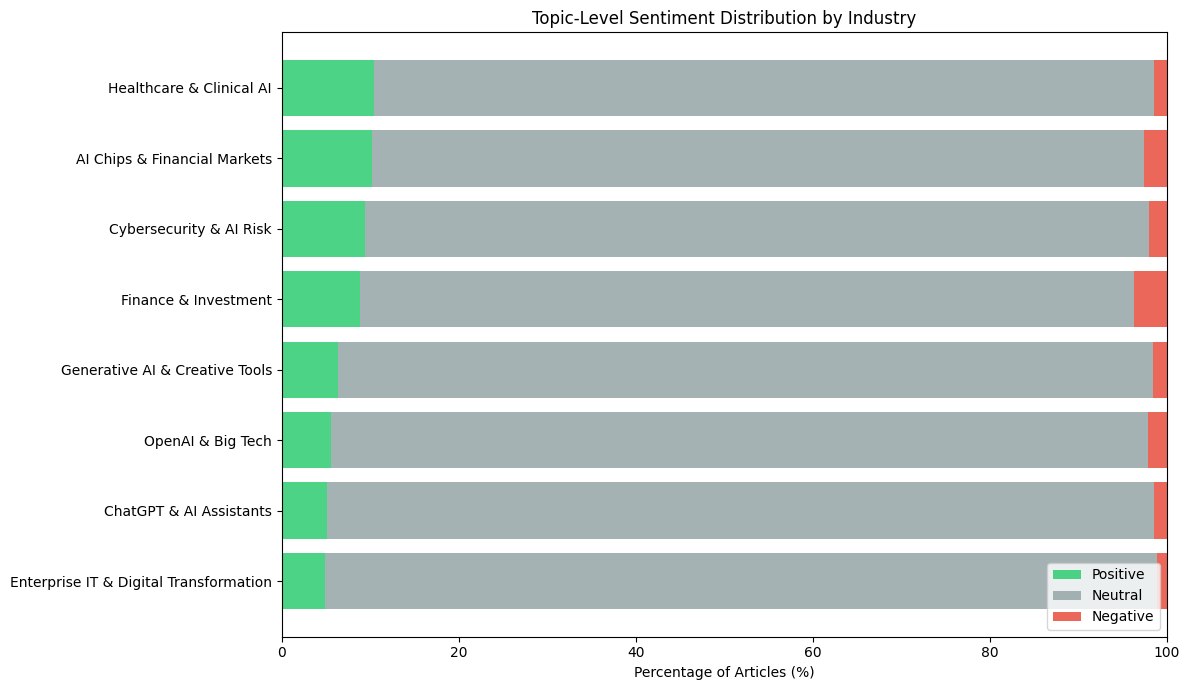


Top 40 organizations after cleaning:
organization
Microsoft                 473
Google                    403
Nasdaq                    322
Apple                     264
OpenAI                    229
Amazon                    137
NASDAQ                    137
NYSE                      124
Samsung                   122
Intel                      97
IBM                        93
Meta                       79
AMD                        64
Nvidia                     64
RSS US                     35
GPU                        35
Size                       32
TEM                        31
GLOBE NEWSWIRE             30
Privacy Policy             30
Computer Weekly            28
Mac                        28
Huawei                     25
Independent                25
Alexa                      24
SES AI                     23
TSMC                       22
Alphabet                   22
Buy Stocks                 21
Mint                       21
GPT                        21
T-Mobile View      

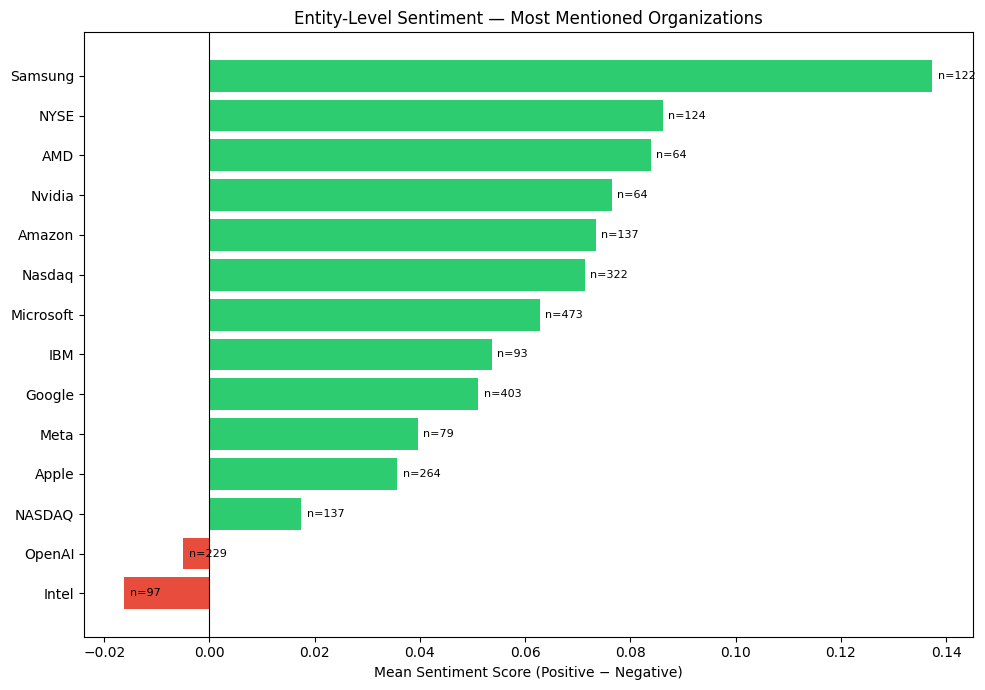

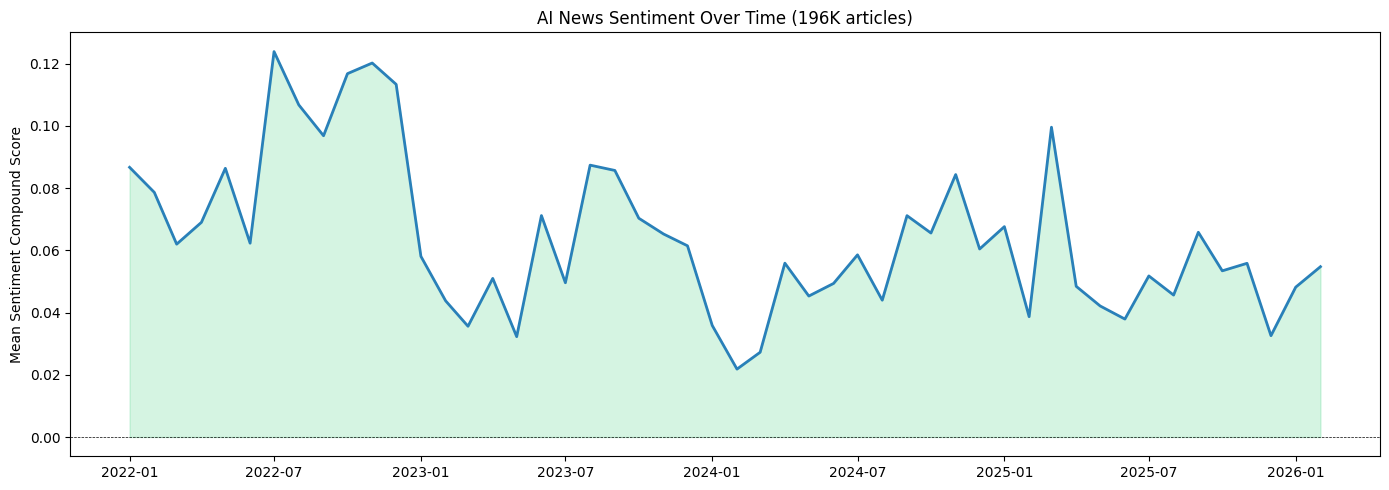

In [5]:
# ── CELL 6: Filter noise before aggregating ───────────────────
import re
import numpy as np
import matplotlib.pyplot as plt

NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}
df_use = df_merged[~df_merged["industry"].isin(NOISE_INDUSTRIES)].copy()
print(f"Articles after removing noise industries: {len(df_use)}")

# Explicit blocklist for known junk that slips through
JUNK_ORGS = {
    "TextShare", "GMT", "COOUpdate", "Region American Europe Arab World",
    "AutomotivePro BizDevUpdate BusinessCommunicationTrends",
    "GadgetsThe Latest Technology", "WebCatalog Desktop",
    "Mobile Service Digital Media Awards", "Financial Services",
    "Android", "Healthcare", "Invest", "CNA", "WPXI", "NBC",
    "BT Bazaar India", "InvestorPlace", "Artificial Intelligence (AI",
    "TechRadar", "TechCrunch",  # media outlets, not companies being analyzed
    "Various Industries", "Android Central", "Android Central Skip",
    "Menu Search", "Today Headline", "CoverageWho",
}

def is_valid_org(name):
    n = str(name).strip()

    # Explicit blocklist
    if n in JUNK_ORGS:
        return False

    # Too short or too long
    if len(n) < 3 or len(n.split()) > 4:
        return False

    # URLs and web artifacts
    if re.search(r"http|www\.|\.com|\.net|\.org|\.co", n.lower()):
        return False

    # Non-ASCII characters (foreign language text)
    if re.search(r"[^\x00-\x7F]", n):
        return False

    # Navigation / UI artifacts
    if re.search(
        r"\b(news|subscribe|cookie|navigation|photo|search|menu|skip|"
        r"headline|coverage|update|digital|media|awards|latest|technology|"
        r"services|industries|healthcare|invest|region|world|desktop|bazaar)\b",
        n.lower()
    ):
        return False

    # Strings that are clearly concatenated nav items (contain 3+ capitalized words run together)
    if re.search(r"[a-z][A-Z][a-z]", n):  # camelCase artifacts like "BizDevUpdate"
        return False

    return True


# ── CELL 7: Topic-level sentiment ─────────────────────────────
topic_sentiment = (
    df_use.groupby("industry")
    .agg(
        article_count=("sentiment_compound", "count"),
        mean_compound=("sentiment_compound", "mean"),
        pct_positive=("sentiment", lambda x: (x == "positive").mean() * 100),
        pct_neutral=("sentiment", lambda x: (x == "neutral").mean() * 100),
        pct_negative=("sentiment", lambda x: (x == "negative").mean() * 100),
    )
    .reset_index()
    .sort_values("mean_compound", ascending=False)
)

print(topic_sentiment.to_string(index=False))

# Stacked bar chart
topic_pivot = topic_sentiment.set_index("industry")[["pct_positive", "pct_neutral", "pct_negative"]]
topic_pivot = topic_pivot.sort_values("pct_positive", ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
left = np.zeros(len(topic_pivot))
for col, color, label in zip(
    ["pct_positive", "pct_neutral", "pct_negative"],
    ["#2ecc71", "#95a5a6", "#e74c3c"],
    ["Positive", "Neutral", "Negative"]
):
    ax.barh(topic_pivot.index, topic_pivot[col], left=left, color=color, label=label, alpha=0.85)
    left += topic_pivot[col].values

ax.set_xlabel("Percentage of Articles (%)")
ax.set_title("Topic-Level Sentiment Distribution by Industry")
ax.legend(loc="lower right")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.savefig(BASE + "topic_sentiment_stacked.png", dpi=150)
plt.show()


# ── CELL 8: Entity-level sentiment (orgs) ─────────────────────

# Step 1: explode and clean
org_long = (
    df_use[["orgs", "sentiment", "sentiment_compound", "industry"]]
    .explode("orgs")
    .rename(columns={"orgs": "organization"})
)
org_long = org_long[org_long["organization"].apply(is_valid_org)]

# Step 2: print raw mention counts to verify cleanup worked
org_counts = org_long["organization"].value_counts()
print("\nTop 40 organizations after cleaning:")
print(org_counts.head(40).to_string())

# Step 3: filter to orgs with 50+ mentions
MIN_MENTIONS = 50
top_orgs = org_counts[org_counts >= MIN_MENTIONS].index
org_long_filtered = org_long[org_long["organization"].isin(top_orgs)]
print(f"\nOrgs with {MIN_MENTIONS}+ mentions: {len(top_orgs)}")

# Step 4: aggregate sentiment per org
org_summary = (
    org_long_filtered.groupby("organization")
    .agg(
        mention_count=("sentiment_compound", "count"),
        mean_sentiment=("sentiment_compound", "mean"),
        pct_positive=("sentiment", lambda x: (x == "positive").mean() * 100),
        pct_negative=("sentiment", lambda x: (x == "negative").mean() * 100),
        pct_neutral=("sentiment", lambda x: (x == "neutral").mean() * 100),
    )
    .reset_index()
    .sort_values("mean_sentiment", ascending=False)
)

print("\nOrg sentiment summary:")
print(org_summary.to_string(index=False))
org_summary.to_csv(BASE + "org_sentiment_summary.csv", index=False)

# Step 5: plot top 15 by mention count
plot_orgs = (
    org_summary.sort_values("mention_count", ascending=False)
    .head(15)
    .sort_values("mean_sentiment")
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in plot_orgs["mean_sentiment"]]
bars = ax.barh(plot_orgs["organization"], plot_orgs["mean_sentiment"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

for bar, count in zip(bars, plot_orgs["mention_count"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"n={count}", va="center", fontsize=8)

ax.set_xlabel("Mean Sentiment Score (Positive − Negative)")
ax.set_title("Entity-Level Sentiment — Most Mentioned Organizations")
plt.tight_layout()
plt.savefig(BASE + "entity_sentiment_orgs.png", dpi=150)
plt.show()


# ── CELL 9: Sentiment over time (uses full 196K df) ───────────
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df_time = df.dropna(subset=["date", "sentiment_compound"]).copy()
df_time["year_month"] = df_time["date"].dt.to_period("M")

time_ts = (
    df_time.groupby("year_month")["sentiment_compound"]
    .mean()
    .reset_index()
)
time_ts["year_month_dt"] = time_ts["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(time_ts["year_month_dt"], time_ts["sentiment_compound"],
        color="#2980b9", linewidth=2)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.fill_between(time_ts["year_month_dt"], time_ts["sentiment_compound"], 0,
                where=time_ts["sentiment_compound"] > 0, alpha=0.2, color="#2ecc71")
ax.fill_between(time_ts["year_month_dt"], time_ts["sentiment_compound"], 0,
                where=time_ts["sentiment_compound"] < 0, alpha=0.2, color="#e74c3c")
ax.set_ylabel("Mean Sentiment Compound Score")
ax.set_title("AI News Sentiment Over Time (196K articles)")
plt.tight_layout()
plt.savefig(BASE + "sentiment_over_time.png", dpi=150)
plt.show()

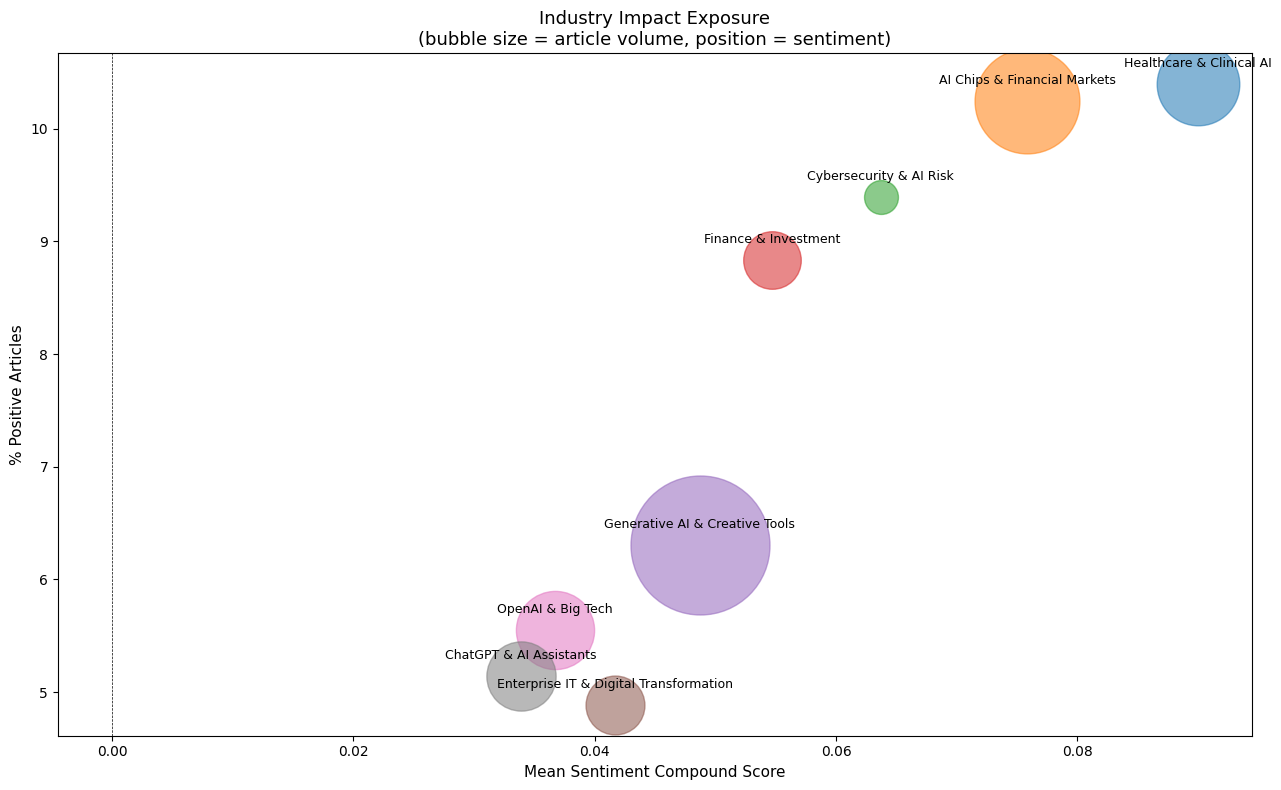

In [43]:
# ── CELL 10 (updated): Bubble chart ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))

for _, row in topic_sentiment.iterrows():
    ax.scatter(
        row["mean_compound"],
        row["pct_positive"],
        s=row["article_count"] * 4,       # increased from 0.8 to 4
        alpha=0.55,
        label=row["industry"]
    )
    ax.annotate(
        row["industry"],
        (row["mean_compound"], row["pct_positive"]),
        fontsize=9, ha="center", va="bottom",
        xytext=(0, 10), textcoords="offset points"
    )

ax.set_xlabel("Mean Sentiment Compound Score", fontsize=11)
ax.set_ylabel("% Positive Articles", fontsize=11)
ax.set_title(
    "Industry Impact Exposure\n(bubble size = article volume, position = sentiment)",
    fontsize=13
)
ax.axvline(0, color="black", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.savefig(BASE + "industry_bubble_chart.png", dpi=150)
plt.show()

In [45]:
!pip install adjustText -q

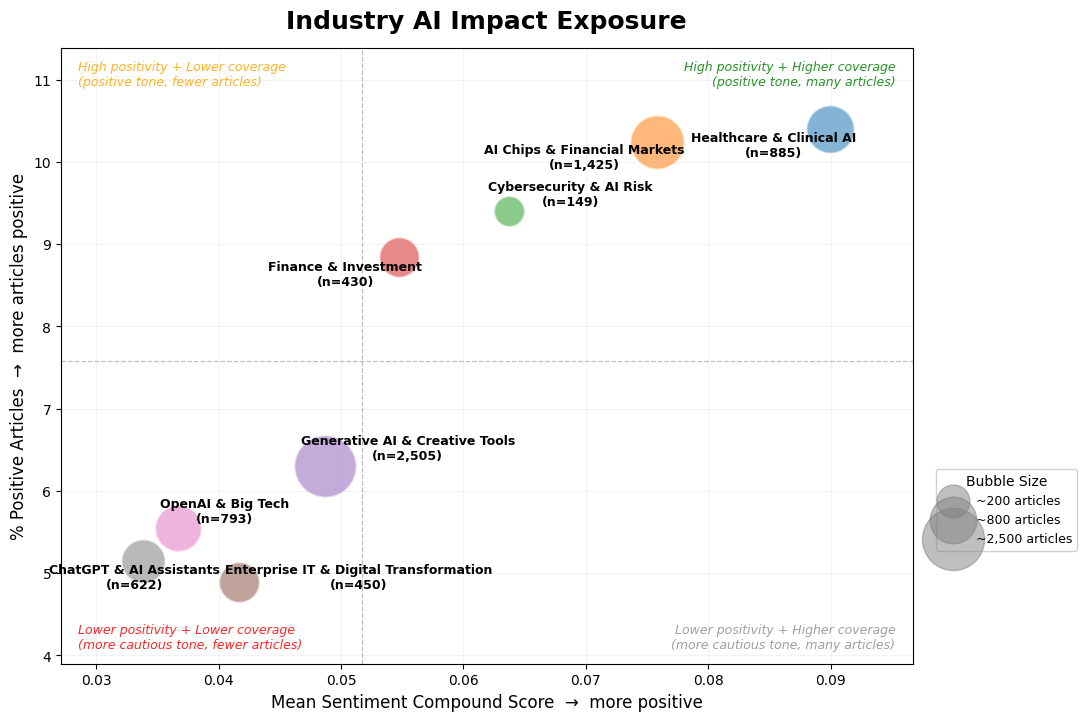

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(13, 8))

max_count = topic_sentiment["article_count"].max()
texts = []

# --- bubbles + initial labels ---
for _, row in topic_sentiment.iterrows():
    size = (np.sqrt(row["article_count"]) / np.sqrt(max_count)) * 2000

    ax.scatter(
        row["mean_compound"], row["pct_positive"],
        s=size, alpha=0.55,
        edgecolors="white", linewidths=1.5
    )

    texts.append(
        ax.text(
            row["mean_compound"], row["pct_positive"],
            f"{row['industry']}\n(n={row['article_count']:,})",
            fontsize=9, ha="center", va="center",
            fontweight="bold"
        )
    )

# --- axis bounds ---
x_min = topic_sentiment["mean_compound"].min()
x_max = topic_sentiment["mean_compound"].max()
y_min = topic_sentiment["pct_positive"].min()
y_max = topic_sentiment["pct_positive"].max()

padding_x = (x_max - x_min) * 0.12
padding_y = (y_max - y_min) * 0.18
ax.set_xlim(x_min - padding_x, x_max + padding_x)
ax.set_ylim(y_min - padding_y, y_max + padding_y)

# --- quadrant lines ---
x_mid = topic_sentiment["mean_compound"].median()
y_mid = topic_sentiment["pct_positive"].median()
ax.axvline(x_mid, color="gray", linewidth=0.9, linestyle="--", alpha=0.5)
ax.axhline(y_mid, color="gray", linewidth=0.9, linestyle="--", alpha=0.5)

# --- Adjust labels WITHOUT arrows first ---
adjust_text(
    texts,
    ax=ax,
    arrowprops=None,                 # key: no arrows on pass 1
    expand_points=(1.8, 1.8),
    expand_text=(1.2, 1.2),
    force_text=(0.15, 0.15),
    force_points=(0.15, 0.15),
)



# --- Corner descriptions (more precise + consistent) ---
ax.text(
    0.02, 0.98,
    "High positivity + Lower coverage\n(positive tone, fewer articles)",
    transform=ax.transAxes,
    fontsize=9, color="orange", alpha=0.85,
    ha="left", va="top", style="italic"
)

ax.text(
    0.98, 0.98,
    "High positivity + Higher coverage\n(positive tone, many articles)",
    transform=ax.transAxes,
    fontsize=9, color="green", alpha=0.85,
    ha="right", va="top", style="italic"
)

ax.text(
    0.02, 0.02,
    "Lower positivity + Lower coverage\n(more cautious tone, fewer articles)",
    transform=ax.transAxes,
    fontsize=9, color="red", alpha=0.85,
    ha="left", va="bottom", style="italic"
)

ax.text(
    0.98, 0.02,
    "Lower positivity + Higher coverage\n(more cautious tone, many articles)",
    transform=ax.transAxes,
    fontsize=9, color="gray", alpha=0.75,
    ha="right", va="bottom", style="italic"
)

# --- Bubble size legend (outside, no overlap) ---
for label, count in [("~200 articles", 200), ("~800 articles", 800), ("~2,500 articles", 2500)]:
    scaled = (np.sqrt(count) / np.sqrt(max_count)) * 2000
    ax.scatter([], [], s=scaled, alpha=0.5, color="gray", label=label)

leg = ax.legend(
    title="Bubble Size",
    loc="center left",
    bbox_to_anchor=(1.02, 0.25),
    fontsize=9,
    framealpha=0.9,
)
leg.get_title().set_fontsize(10)

# --- labels + simpler title ---
ax.set_xlabel("Mean Sentiment Compound Score  →  more positive", fontsize=12)
ax.set_ylabel("% Positive Articles  →  more articles positive", fontsize=12)
ax.set_title("Industry AI Impact Exposure", fontsize=18, fontweight="bold", pad=14)

ax.grid(alpha=0.15)
fig.subplots_adjust(right=0.78)

plt.savefig(BASE + "industry_bubble_chart.png", dpi=150, bbox_inches="tight")
plt.show()

In [30]:
print(df_merged.columns)

Index(['url', 'title', 'clean_text', 'text_len', 'domain', 'text_bt',
       'topic_id', 'ner_text', 'orgs_raw', 'orgs', 'tech_terms', 'industry',
       'sentiment', 'sentiment_compound', 'neg_score', 'neu_score',
       'pos_score', 'date'],
      dtype='object')


In [33]:
print(type(df_merged))
print(df_merged.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['url', 'title', 'clean_text', 'text_len', 'domain', 'text_bt',
       'topic_id', 'ner_text', 'orgs_raw', 'orgs', 'tech_terms', 'industry',
       'sentiment', 'sentiment_compound', 'neg_score', 'neu_score',
       'pos_score', 'date'],
      dtype='object')


In [40]:
df_merged["date"] = pd.to_datetime(df_merged["date"], errors="coerce")
df_merged = df_merged.dropna(subset=["date"]).copy()

In [60]:
url_to_industry = df_merged[["url", "industry"]].drop_duplicates(subset="url")

df_with_industry = df.merge(url_to_industry, on="url", how="left")
df_with_industry["date"] = pd.to_datetime(df_with_industry["date"], errors="coerce")
print(df_with_industry.columns)
print("industry in df_with_industry?", "industry" in df_with_industry.columns)


Index(['url', 'title', 'clean_text', 'text_len', 'domain', 'text_bt',
       'topic_id', 'ner_text', 'orgs_raw', 'orgs', 'tech_terms', 'industry_x',
       'sentiment', 'sentiment_compound', 'neg_score', 'neu_score',
       'pos_score', 'date', 'industry_y'],
      dtype='object')
industry in df_with_industry? False


In [61]:
# Combine the two industry columns into one clean column
df_with_industry["industry"] = (
    df_with_industry["industry_y"]
    .combine_first(df_with_industry["industry_x"])
)

# Drop the old suffix columns
df_with_industry = df_with_industry.drop(columns=["industry_x", "industry_y"])

In [62]:
print(df_with_industry["industry"].isna().mean(), "fraction missing industry")

0.0 fraction missing industry


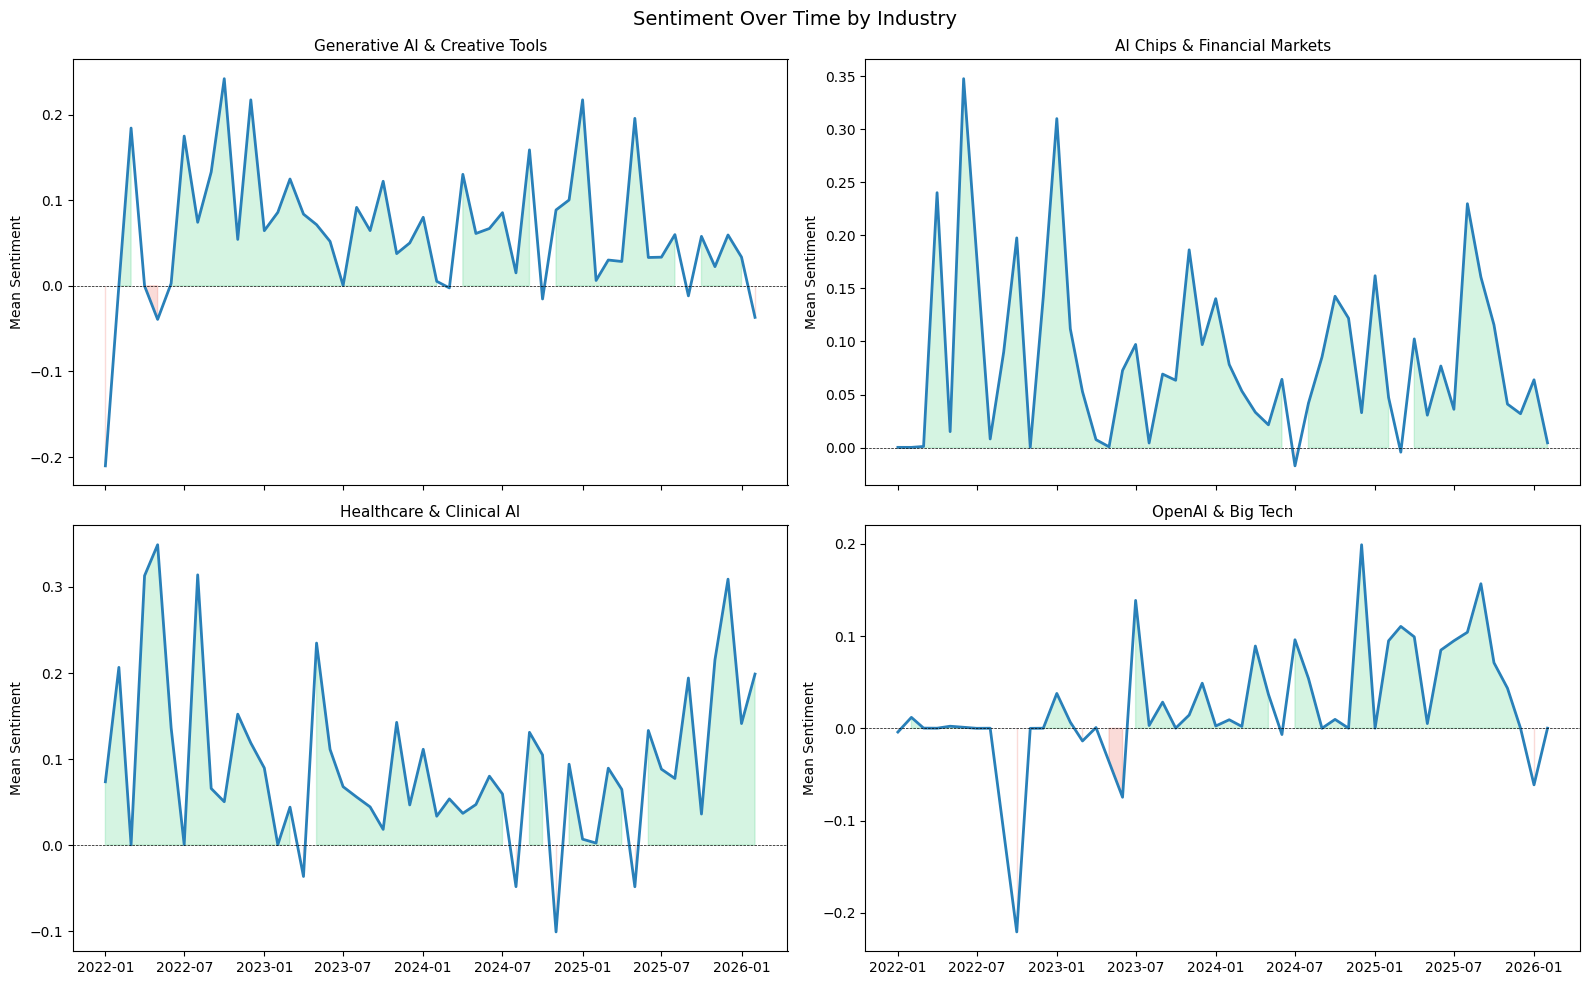

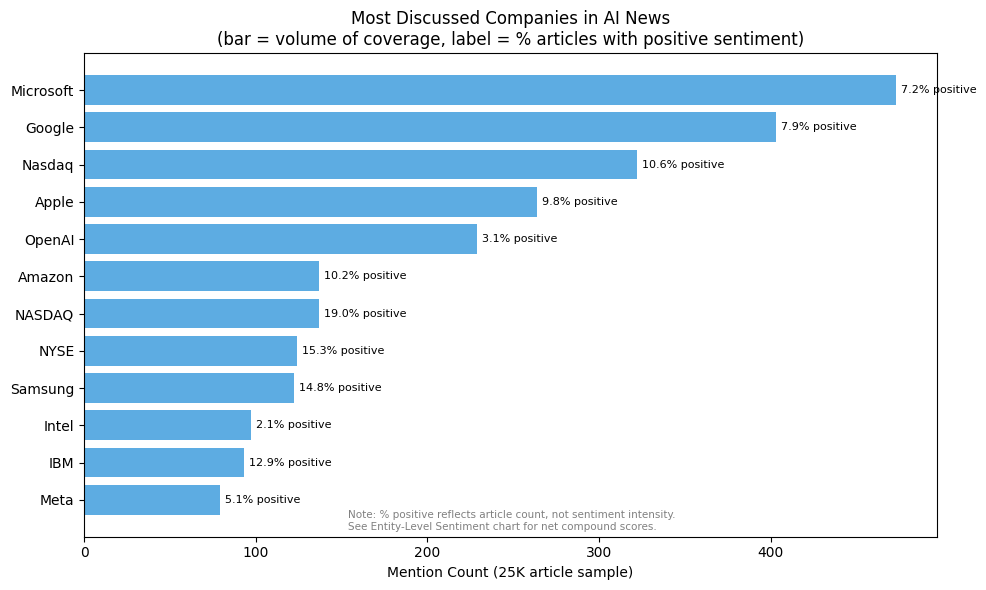

Tech terms after cleaning: 6299

Top 30 technologies by mention count:
technology
gpt                     2354
rag                      924
chatbot                  543
agent                    463
gpu                      306
agents                   201
lora                     187
gemini                   187
bert                     163
llm                      144
copilot                  135
claude                   125
deepfake                 123
agentic                  111
large language model      79
malware                   35
dall-e                    32
diffusion                 26
stable diffusion          21
tpu                       20
inference                 20
phishing                  18
midjourney                17
.5                        10
vector database           10
transformer                8
h100                       8
fine-tuning                8
prompt engineering         5
.1                         4


In [63]:
# ── CELL 11: Sentiment over time BY INDUSTRY (top 4) ──────────
# Fix: join industry from df_merged onto df (which has date)

# # Build url -> industry lookup from df_merged
# url_to_industry = df_merged[["url", "industry"]].drop_duplicates(subset="url")

# # Join industry onto full df
# df_with_industry = df.merge(url_to_industry, on="url", how="left")
# df_with_industry["date"] = pd.to_datetime(df_with_industry["date"], errors="coerce")

top_4 = (
    topic_sentiment.sort_values("article_count", ascending=False)
    .head(4)["industry"].tolist()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.flatten()

for i, industry in enumerate(top_4):
    df_ind = df_with_industry[df_with_industry["industry"] == industry].copy()
    df_ind["year_month"] = df_ind["date"].dt.to_period("M")
    ts = (
        df_ind.groupby("year_month")["sentiment_compound"]
        .mean()
        .reset_index()
    )
    ts["year_month_dt"] = ts["year_month"].dt.to_timestamp()

    axes[i].plot(ts["year_month_dt"], ts["sentiment_compound"],
                 linewidth=2, color="#2980b9")
    axes[i].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[i].fill_between(ts["year_month_dt"], ts["sentiment_compound"], 0,
                         where=ts["sentiment_compound"] > 0,
                         alpha=0.2, color="#2ecc71")
    axes[i].fill_between(ts["year_month_dt"], ts["sentiment_compound"], 0,
                         where=ts["sentiment_compound"] < 0,
                         alpha=0.2, color="#e74c3c")
    axes[i].set_title(industry, fontsize=11)
    axes[i].set_ylabel("Mean Sentiment")

plt.suptitle("Sentiment Over Time by Industry", fontsize=14)
plt.tight_layout()
plt.savefig(BASE + "sentiment_over_time_by_industry.png", dpi=150)
plt.show()

# ── CELL 12 (updated): Org mention volume ─────────────────────
# Renamed title + added note to avoid confusion with sentiment chart
org_volume = org_summary.sort_values("mention_count", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    org_volume["organization"][::-1],
    org_volume["mention_count"][::-1],
    color="#3498db", alpha=0.8
)
ax.set_xlabel("Mention Count (25K article sample)")
ax.set_title(
    "Most Discussed Companies in AI News\n"
    "(bar = volume of coverage, label = % articles with positive sentiment)"
)
for i, (count, pct_pos) in enumerate(
    zip(org_volume["mention_count"][::-1], org_volume["pct_positive"][::-1])
):
    ax.text(count + 3, i, f"{pct_pos:.1f}% positive", va="center", fontsize=8)

ax.annotate(
    "Note: % positive reflects article count, not sentiment intensity.\n"
    "See Entity-Level Sentiment chart for net compound scores.",
    xy=(0.31, 0.01), xycoords="axes fraction",
    fontsize=7.5, color="gray", va="bottom"
)
plt.tight_layout()
plt.savefig(BASE + "org_mention_volume.png", dpi=150)
plt.show()


# ── CELL 13: Technology visuals ───────────────────────────────
import ast

# Parse tech_terms from df_merged
def parse_list_col(val):
    if isinstance(val, list): return val
    if pd.isna(val) or str(val) in ("", "[]", "nan"): return []
    try: return ast.literal_eval(val)
    except: return []

df_merged["tech_parsed"] = df_merged["tech_terms"].apply(parse_list_col)

# Clean tech strings (same issue as orgs — strip brackets)
def clean_tech(val):
    return re.sub(r"[\[\]']", "", str(val)).strip().lower()

# Explode tech terms
tech_long = (
    df_merged[["tech_parsed", "sentiment", "sentiment_compound", "industry"]]
    .explode("tech_parsed")
    .rename(columns={"tech_parsed": "technology"})
)
tech_long["technology"] = tech_long["technology"].apply(clean_tech)
tech_long = tech_long[
    tech_long["technology"].notna() &
    (tech_long["technology"] != "") &
    (tech_long["technology"] != "nan") &
    (tech_long["technology"].str.len() > 1)
]

print(f"Tech terms after cleaning: {len(tech_long)}")
print("\nTop 30 technologies by mention count:")
print(tech_long["technology"].value_counts().head(30).to_string())

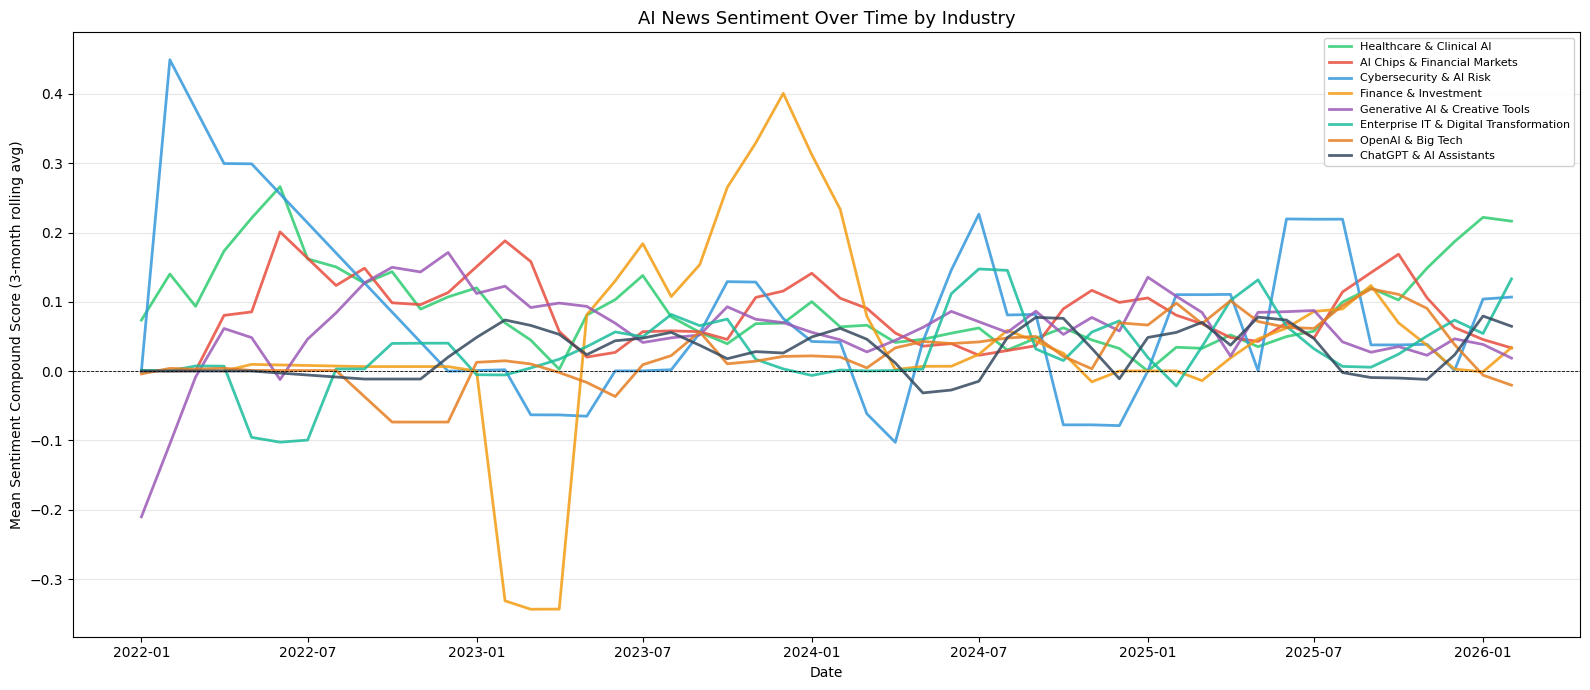

In [64]:
# ── CELL 11 (updated): All industries on single line chart ────
df_with_industry["date"] = pd.to_datetime(df_with_industry["date"], errors="coerce")

NOISE_INDUSTRIES = {"Outlier / Unclustered", "Other / Mixed"}
all_industries = topic_sentiment[
    ~topic_sentiment["industry"].isin(NOISE_INDUSTRIES)
]["industry"].tolist()

fig, ax = plt.subplots(figsize=(16, 7))

# Color palette — one color per industry
colors = [
    "#2ecc71", "#e74c3c", "#3498db", "#f39c12",
    "#9b59b6", "#1abc9c", "#e67e22", "#34495e"
]

for i, industry in enumerate(all_industries):
    df_ind = df_with_industry[df_with_industry["industry"] == industry].copy()
    df_ind["year_month"] = df_ind["date"].dt.to_period("M")
    ts = (
        df_ind.groupby("year_month")["sentiment_compound"]
        .mean()
        .reset_index()
    )
    ts["year_month_dt"] = ts["year_month"].dt.to_timestamp()

    # Smooth with rolling average to reduce noise
    ts["smoothed"] = ts["sentiment_compound"].rolling(window=3, min_periods=1).mean()

    ax.plot(
        ts["year_month_dt"], ts["smoothed"],
        linewidth=2, label=industry,
        color=colors[i % len(colors)], alpha=0.85
    )

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_ylabel("Mean Sentiment Compound Score (3-month rolling avg)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.set_title("AI News Sentiment Over Time by Industry", fontsize=13)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(BASE + "sentiment_over_time_by_industry.png", dpi=150)
plt.show()

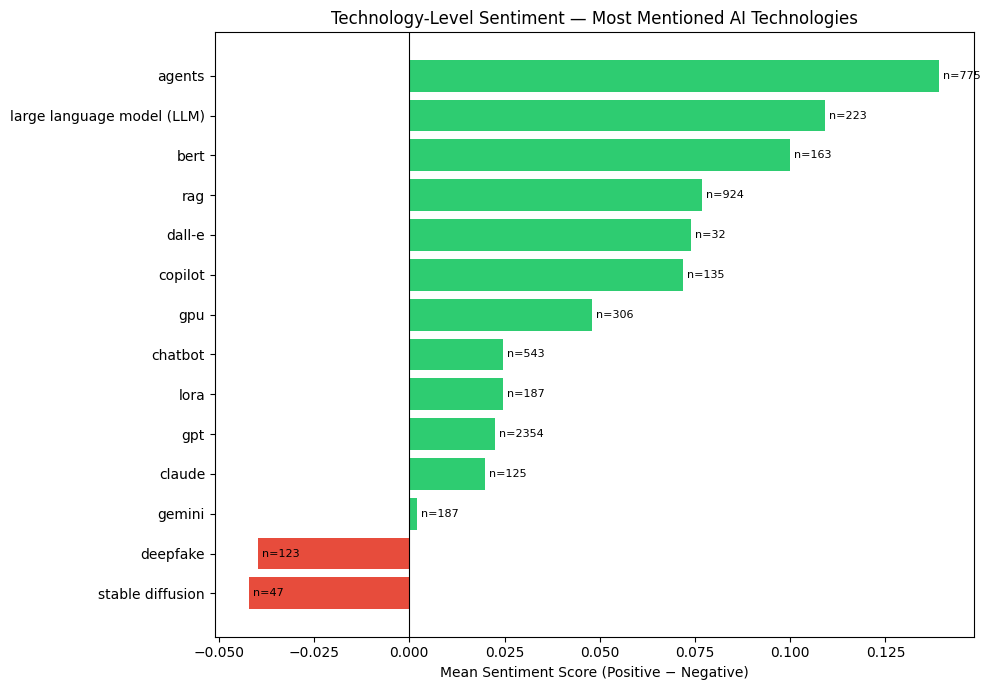

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re, ast

# -----------------------------
# 1) Copy master dataframe
# -----------------------------
df = df_merged.copy()

# -----------------------------
# 2) Parse tech_terms robustly
# -----------------------------
def parse_tech_terms(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()

    # Handle stringified lists
    if s.startswith("[") and s.endswith("]"):
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return parsed
        except:
            pass

    # Fallback: split by comma
    return [t.strip() for t in s.split(",") if t.strip()]

df["tech_terms_list"] = df["tech_terms"].apply(parse_tech_terms)

df_tech = df.explode("tech_terms_list").copy()
df_tech["tech_terms_list"] = (
    df_tech["tech_terms_list"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# -----------------------------
# 3) Normalize technology names
# -----------------------------
def normalize_tech(t):
    t = str(t).strip().lower()
    t = t.replace("·", "-")

    # LLM variants
    if t in {"llm", "llms", "large language model", "large language models"}:
        return "large language model (LLM)"

    # Agent variants
    if t in {"agent", "agents", "agentic", "agent_agents"}:
        return "agents"

    # Diffusion variants
    if t in {"diffusion", "stable diffusion", "stable-diffusion", "sd"}:
        return "stable diffusion"

    # DALL-E variants
    if t in {"dalle", "dall-e", "dall-e2", "dall-e 2", "dall-e 3", "dall-e3"}:
        return "dall-e"

    return re.sub(r"[_\s]+", " ", t).strip()

df_tech["technology"] = df_tech["tech_terms_list"].apply(normalize_tech)

# -----------------------------
# 4) Remove junk + generic pipeline terms
# -----------------------------
exclude_terms = {
    "nan", "none", "null", "",
    "malware",
    "inference", "training", "model", "deployment"
}

df_tech = df_tech[
    (df_tech["technology"].notna()) &
    (~df_tech["technology"].isin(exclude_terms)) &
    (df_tech["technology"].str.len() > 2) &
    (~df_tech["technology"].str.fullmatch(r"[^a-zA-Z]+"))
].copy()

# -----------------------------
# 5) Aggregate sentiment
# -----------------------------
tech_summary = (
    df_tech.groupby("technology")
    .agg(
        mention_count=("technology", "size"),
        mean_sentiment=("sentiment_compound", "mean"),
    )
    .reset_index()
    .sort_values("mention_count", ascending=False)
)

# -----------------------------
# 6) Plot top 14 technologies
# -----------------------------
plot_tech = tech_summary.head(14).sort_values("mean_sentiment")

fig, ax = plt.subplots(figsize=(10, 7))

colors = ["#e74c3c" if x < 0 else "#2ecc71"
          for x in plot_tech["mean_sentiment"]]

bars = ax.barh(plot_tech["technology"],
               plot_tech["mean_sentiment"],
               color=colors)

ax.axvline(0, color="black", linewidth=0.8)

for bar, count in zip(bars, plot_tech["mention_count"]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"n={count}",
        va="center",
        fontsize=8
    )

ax.set_xlabel("Mean Sentiment Score (Positive − Negative)")
ax.set_title("Technology-Level Sentiment — Most Mentioned AI Technologies")

plt.tight_layout()
plt.savefig(BASE + "tech_sentiment_bar.png", dpi=150)
plt.show()


Technology sentiment summary:
          technology  mention_count  mean_sentiment  pct_positive  pct_negative
                 gpt           2354        0.022435      4.672897      2.293968
                 rag            924        0.076818     10.173160      3.354978
             chatbot            543        0.024629      4.972376      2.025783
               agent            463        0.131925     14.038877      0.431965
                 gpu            306        0.048042      5.882353      2.287582
              agents            201        0.186010     20.398010      0.497512
                lora            187        0.024562      2.673797      1.069519
              gemini            187        0.002079      3.743316      3.208556
                bert            163        0.099875     11.042945      0.000000
                 llm            144        0.097943     10.416667      0.694444
             copilot            135        0.071934      7.407407      0.740741
         

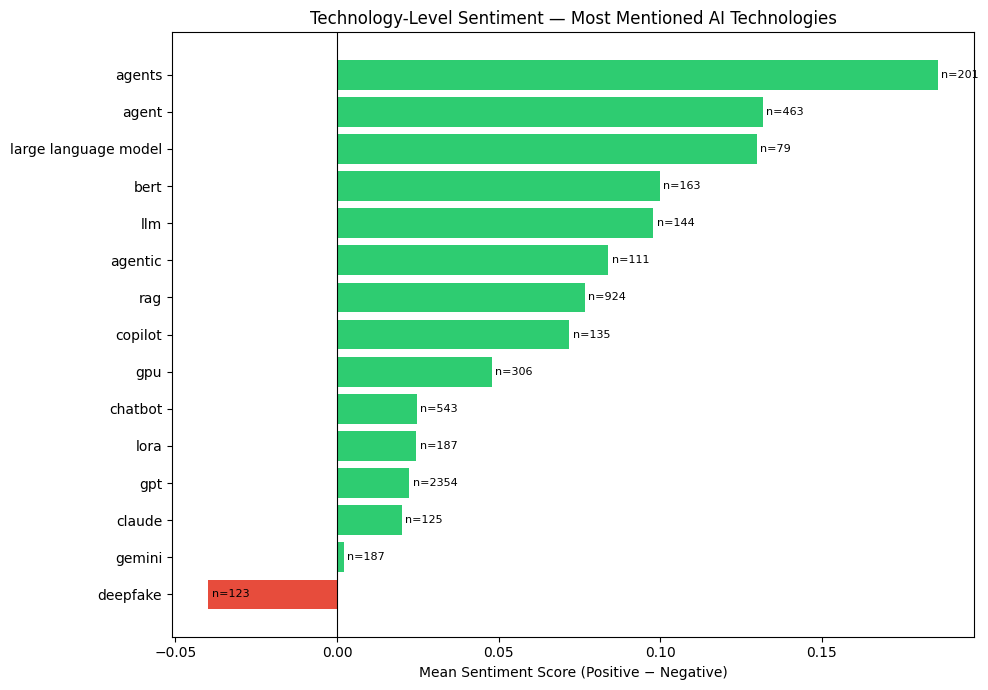

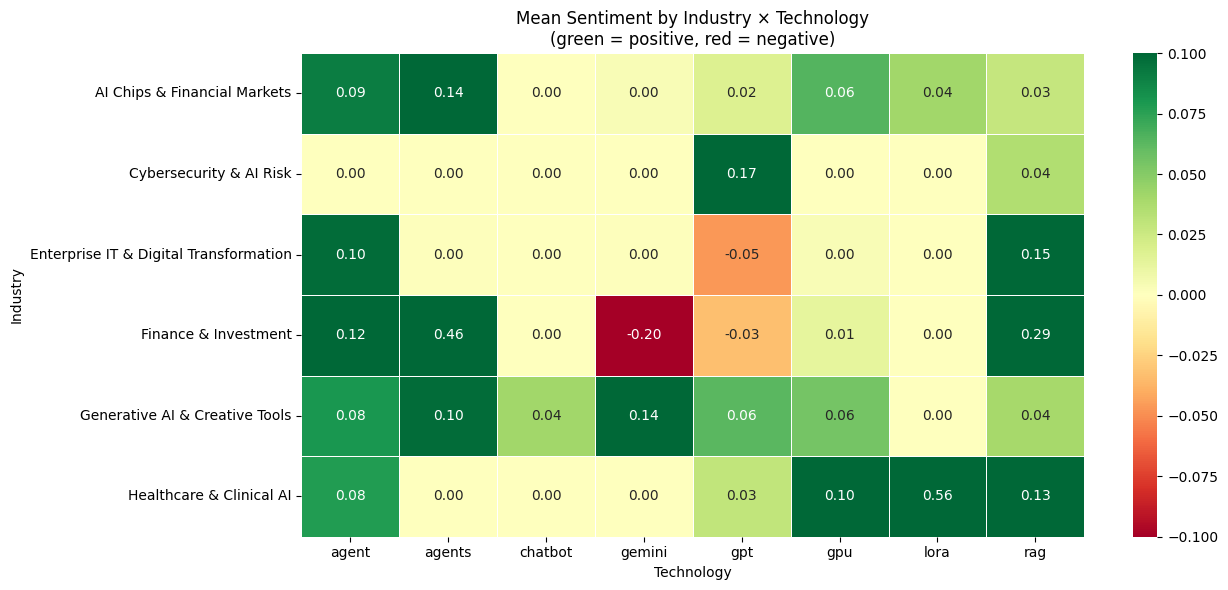

In [66]:
# ── CELL 13b: Technology sentiment bar chart ──────────────────
tech_counts = tech_long["technology"].value_counts()
MIN_TECH_MENTIONS = 5
top_tech = tech_counts[tech_counts >= MIN_TECH_MENTIONS].index

tech_summary = (
    tech_long[tech_long["technology"].isin(top_tech)]
    .groupby("technology")
    .agg(
        mention_count=("sentiment_compound", "count"),
        mean_sentiment=("sentiment_compound", "mean"),
        pct_positive=("sentiment", lambda x: (x == "positive").mean() * 100),
        pct_negative=("sentiment", lambda x: (x == "negative").mean() * 100),
    )
    .reset_index()
    .sort_values("mention_count", ascending=False)
)

print("\nTechnology sentiment summary:")
print(tech_summary.head(20).to_string(index=False))
tech_summary.to_csv(BASE + "tech_sentiment_summary.csv", index=False)

# Plot top 15 most mentioned technologies by sentiment
plot_tech = tech_summary.head(15).sort_values("mean_sentiment")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if x < 0 else "#2ecc71" for x in plot_tech["mean_sentiment"]]
bars = ax.barh(plot_tech["technology"], plot_tech["mean_sentiment"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)

for bar, count in zip(bars, plot_tech["mention_count"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"n={count}", va="center", fontsize=8)

ax.set_xlabel("Mean Sentiment Score (Positive − Negative)")
ax.set_title("Technology-Level Sentiment — Most Mentioned AI Technologies")
plt.tight_layout()
plt.savefig(BASE + "tech_sentiment_bar.png", dpi=150)
plt.show()


# ── CELL 13c: Technology × Industry heatmap ───────────────────
# Shows which technologies are driving each industry's coverage
# Directly answers "by what means will industries be impacted"

# Get top 8 technologies and top 6 industries by volume
top_8_tech = tech_summary.head(8)["technology"].tolist()
top_6_industries = topic_sentiment.head(6)["industry"].tolist()

tech_industry = (
    tech_long[
        tech_long["technology"].isin(top_8_tech) &
        tech_long["industry"].isin(top_6_industries)
    ]
    .groupby(["industry", "technology"])["sentiment_compound"]
    .mean()
    .reset_index()
    .pivot(index="industry", columns="technology", values="sentiment_compound")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    tech_industry,
    cmap="RdYlGn", center=0,
    annot=True, fmt=".2f",
    linewidths=0.5, ax=ax,
    vmin=-0.1, vmax=0.1
)
ax.set_title("Mean Sentiment by Industry × Technology\n(green = positive, red = negative)")
ax.set_xlabel("Technology")
ax.set_ylabel("Industry")
plt.tight_layout()
plt.savefig(BASE + "tech_industry_heatmap.png", dpi=150)
plt.show()

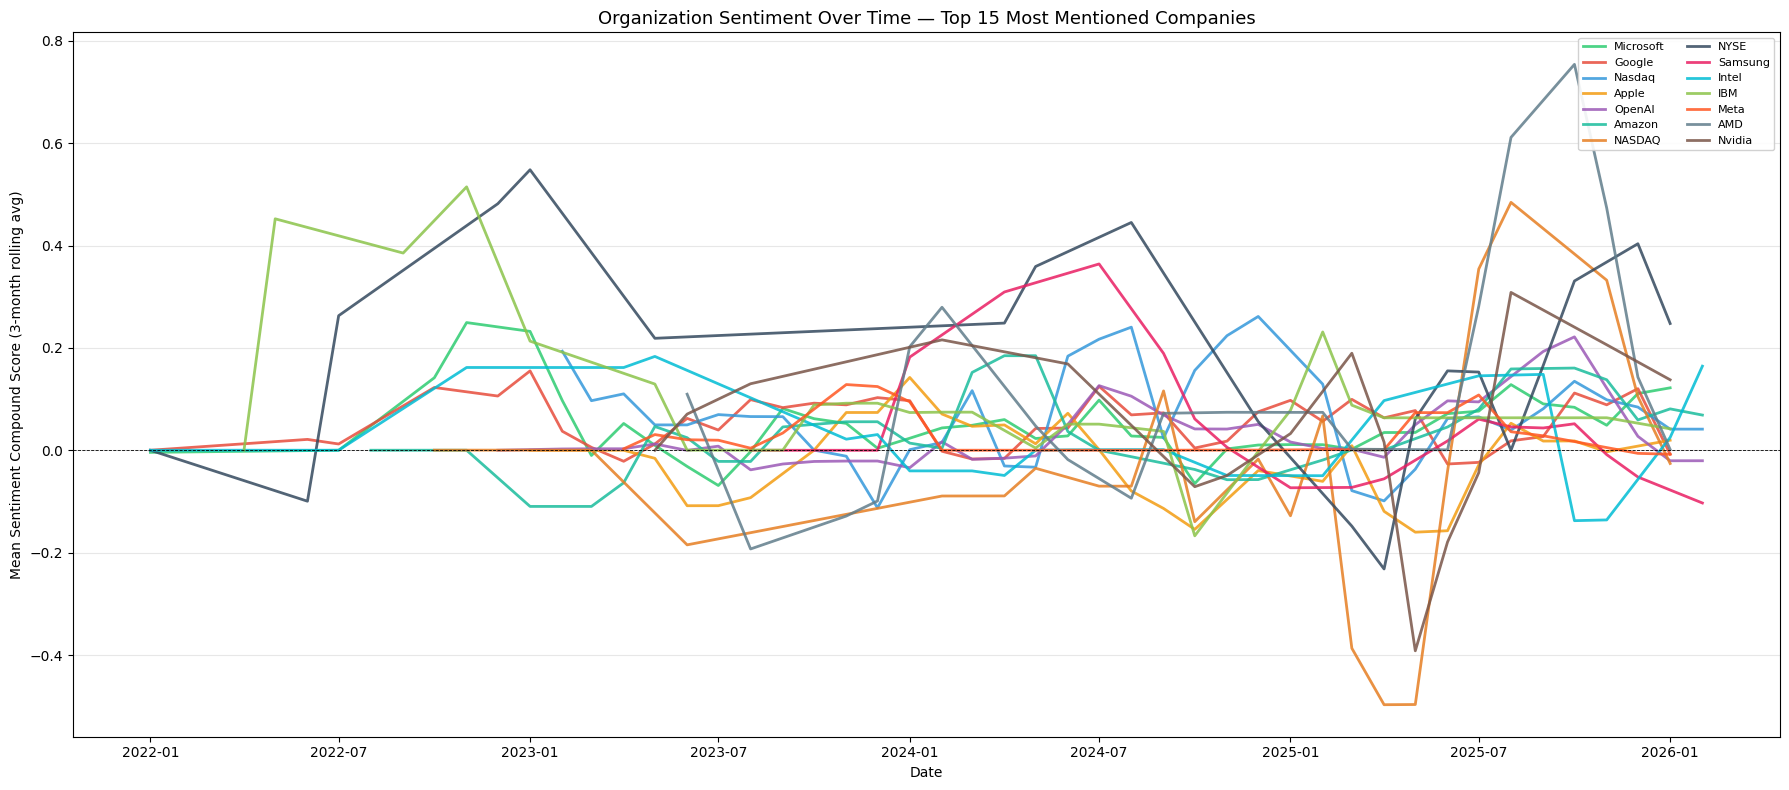

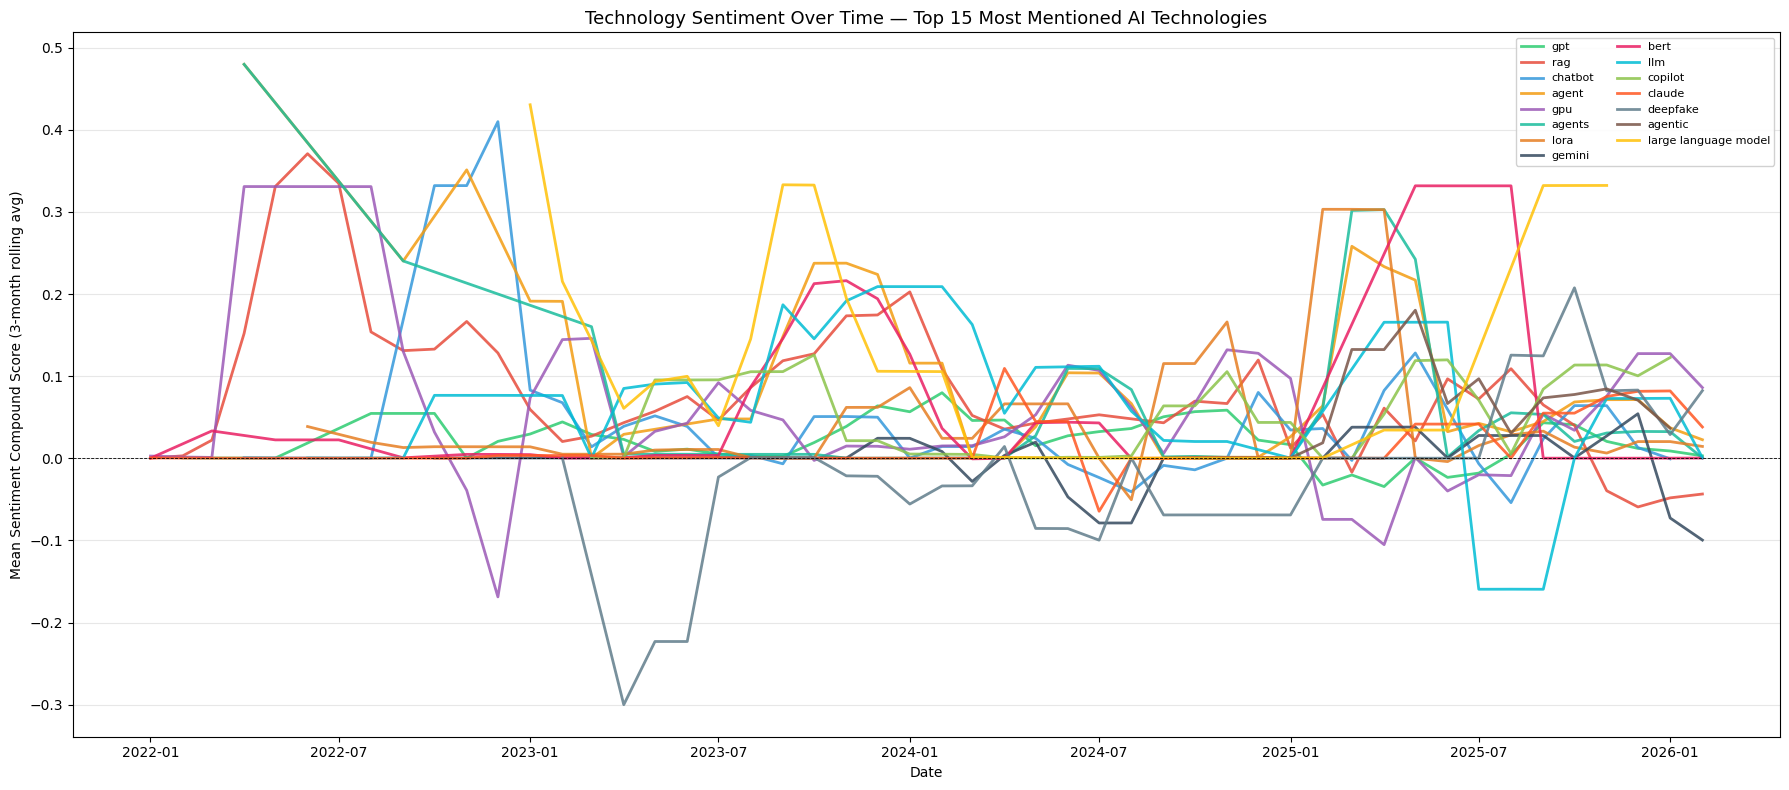

In [67]:
# ── CELL 14 (updated): Organization sentiment over time ───────
org_time_long = (
    df_merged[["url", "orgs"]]
    .explode("orgs")
    .rename(columns={"orgs": "organization"})
)
org_time_long = org_time_long[org_time_long["organization"].apply(is_valid_org)]
org_time_long = org_time_long.merge(
    df[["url", "sentiment_compound", "date"]], on="url", how="left"
)
org_time_long["date"] = pd.to_datetime(org_time_long["date"], errors="coerce")
org_time_long["year_month"] = org_time_long["date"].dt.to_period("M")

top_15_orgs = (
    org_summary.sort_values("mention_count", ascending=False)
    .head(15)["organization"].tolist()
)

colors_15 = [
    "#2ecc71", "#e74c3c", "#3498db", "#f39c12", "#9b59b6",
    "#1abc9c", "#e67e22", "#34495e", "#e91e63", "#00bcd4",
    "#8bc34a", "#ff5722", "#607d8b", "#795548", "#ffc107"
]

fig, ax = plt.subplots(figsize=(18, 8))

for i, org in enumerate(top_15_orgs):
    df_org = org_time_long[org_time_long["organization"] == org].copy()

    ts = df_org.groupby("year_month")["sentiment_compound"].mean().reset_index()

    # ── Fix: only keep months with 3+ articles ────────────────
    monthly_counts = df_org.groupby("year_month").size().reset_index(name="n")
    ts = ts.merge(monthly_counts, on="year_month", how="left")
    ts = ts[ts["n"] >= 3]

    if len(ts) < 3:  # skip orgs with too little data after filtering
        continue

    ts["year_month_dt"] = ts["year_month"].dt.to_timestamp()
    ts["smoothed"] = ts["sentiment_compound"].rolling(window=3, min_periods=1).mean()

    ax.plot(
        ts["year_month_dt"], ts["smoothed"],
        linewidth=2, label=org,
        color=colors_15[i], alpha=0.85
    )

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_ylabel("Mean Sentiment Compound Score (3-month rolling avg)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.set_title("Organization Sentiment Over Time — Top 15 Most Mentioned Companies", fontsize=13)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(BASE + "org_sentiment_over_time.png", dpi=150)
plt.show()


# ── CELL 15: Technology sentiment over time (top 15) ──────────
tech_time_long = (
    df_merged[["url", "tech_parsed"]]
    .explode("tech_parsed")
    .rename(columns={"tech_parsed": "technology"})
)
tech_time_long["technology"] = (
    tech_time_long["technology"]
    .apply(lambda x: re.sub(r"[\[\]']", "", str(x)).strip().lower())
)
tech_time_long = tech_time_long[
    tech_time_long["technology"].notna() &
    (tech_time_long["technology"] != "") &
    (tech_time_long["technology"] != "nan") &
    (tech_time_long["technology"].str.len() > 1)
]
tech_time_long = tech_time_long.merge(
    df[["url", "sentiment_compound", "date"]], on="url", how="left"
)
tech_time_long["date"] = pd.to_datetime(tech_time_long["date"], errors="coerce")

# Match exactly 15 techs shown in technology sentiment bar chart
top_15_tech = (
    tech_summary.sort_values("mention_count", ascending=False)
    .head(15)["technology"].tolist()
)

fig, ax = plt.subplots(figsize=(18, 8))

for i, tech in enumerate(top_15_tech):
    df_tech = tech_time_long[tech_time_long["technology"] == tech].copy()
    df_tech["year_month"] = df_tech["date"].dt.to_period("M")
    ts = (
        df_tech.groupby("year_month")["sentiment_compound"]
        .mean()
        .reset_index()
    )
    ts["year_month_dt"] = ts["year_month"].dt.to_timestamp()
    ts["smoothed"] = ts["sentiment_compound"].rolling(window=3, min_periods=1).mean()

    ax.plot(
        ts["year_month_dt"], ts["smoothed"],
        linewidth=2, label=tech,
        color=colors_15[i], alpha=0.85
    )

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_ylabel("Mean Sentiment Compound Score (3-month rolling avg)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.set_title("Technology Sentiment Over Time — Top 15 Most Mentioned AI Technologies", fontsize=13)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9, ncol=2)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(BASE + "tech_sentiment_over_time.png", dpi=150)
plt.show()

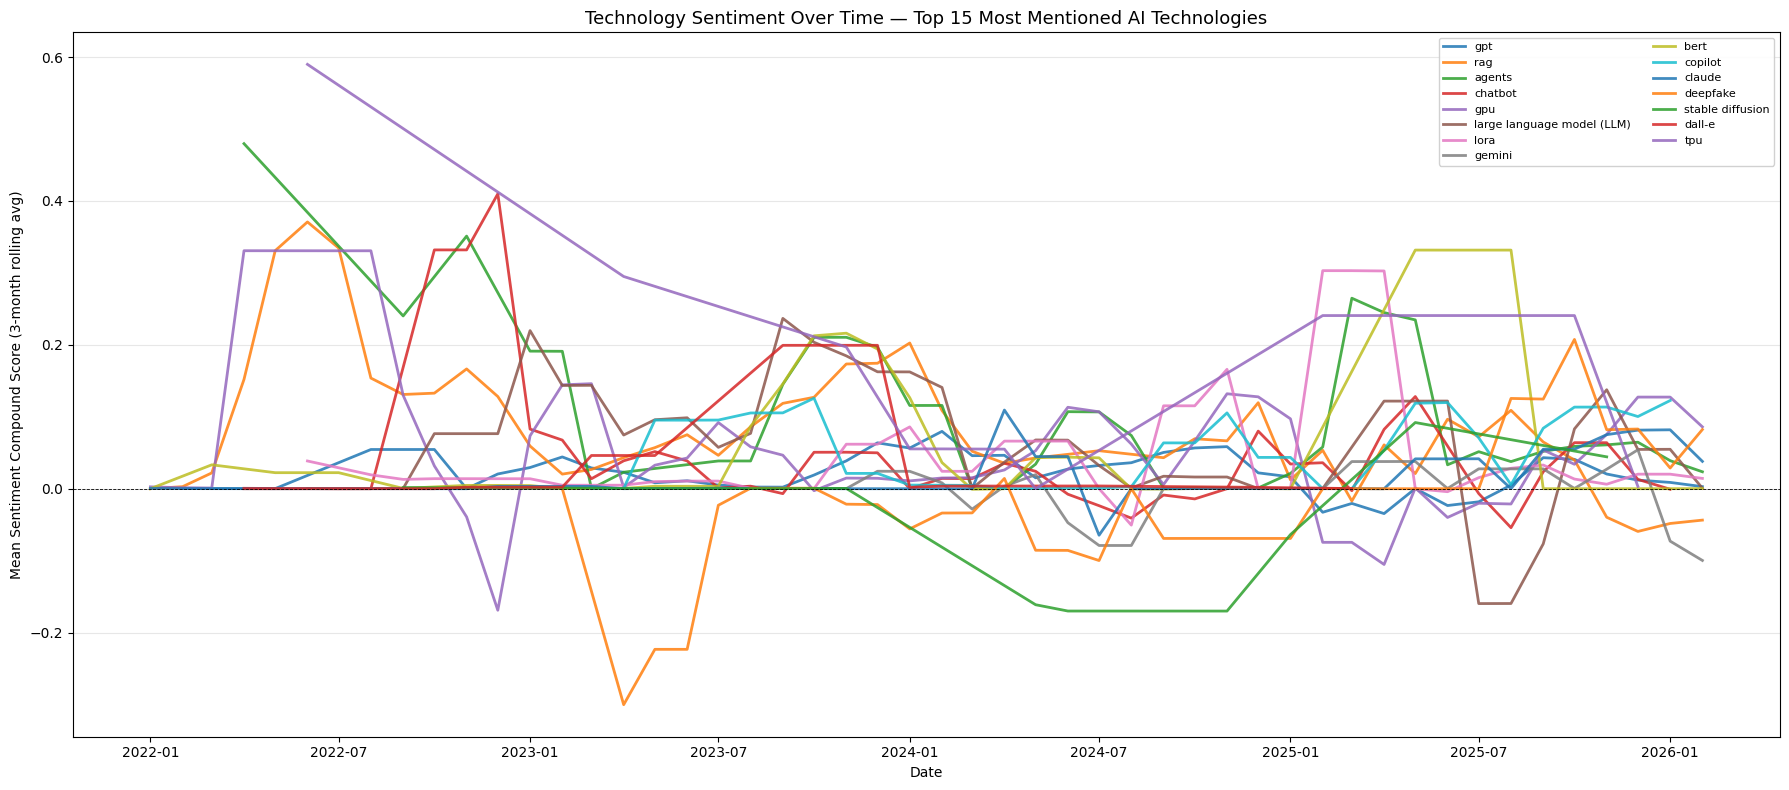

In [73]:
# ── CELL 15: Technology sentiment over time (top 15) ──────────
import re
import pandas as pd

# 1) Build long tech table from df_merged (sample w/ tech_parsed)
tech_time_long = (
    df_merged[["url", "tech_parsed"]]
    .explode("tech_parsed")
    .rename(columns={"tech_parsed": "technology"})
)

# 2) Clean raw strings
tech_time_long["technology"] = (
    tech_time_long["technology"]
    .apply(lambda x: re.sub(r"[\[\]']", "", str(x)).strip().lower())
)

tech_time_long = tech_time_long[
    tech_time_long["technology"].notna() &
    (tech_time_long["technology"] != "") &
    (tech_time_long["technology"] != "nan") &
    (tech_time_long["technology"].str.len() > 1)
].copy()

# 3) Normalize names:
#    - LLM == large language model
#    - agent/agents/agentic == agents
#    - diffusion == stable diffusion
def normalize_tech(t):
    t = str(t).strip().lower()
    t = t.replace("·", "-")

    # Merge LLM variants
    if t in {"llm", "llms", "large language model", "large language models"}:
        return "large language model (LLM)"

    # Merge agent variants
    if t in {"agent", "agents", "agentic", "agent_agents"}:
        return "agents"

    # Merge diffusion variants
    if t in {"diffusion", "stable diffusion", "stable-diffusion", "sd"}:
        return "stable diffusion"

    return t

tech_time_long["technology"] = tech_time_long["technology"].apply(normalize_tech)

# 4) Remove unwanted non-tech / junk terms
exclude_terms = {"malware", "nan", "none", "null", ""}
tech_time_long = tech_time_long[~tech_time_long["technology"].isin(exclude_terms)].copy()

# Optional: remove 1–2 character artifacts if any slip through
tech_time_long = tech_time_long[tech_time_long["technology"].str.len() > 2].copy()

# 5) Join sentiment + date from full df (df should have url, sentiment_compound, date)
tech_time_long = tech_time_long.merge(
    df[["url", "sentiment_compound", "date"]],
    on="url",
    how="left"
)

tech_time_long["date"] = pd.to_datetime(tech_time_long["date"], errors="coerce")
tech_time_long = tech_time_long.dropna(subset=["date"]).copy()

# 6) Pick top 15 technologies AFTER normalization/cleaning
top_15_tech = (
    tech_time_long["technology"]
    .value_counts()
    .head(15)
    .index
    .tolist()
)

# 7) Plot rolling 3-month mean sentiment over time
fig, ax = plt.subplots(figsize=(18, 8))

for tech in top_15_tech:
    df_t = tech_time_long[tech_time_long["technology"] == tech].copy()
    df_t["year_month"] = df_t["date"].dt.to_period("M")

    ts = (
        df_t.groupby("year_month")["sentiment_compound"]
        .mean()
        .reset_index()
    )

    ts["year_month_dt"] = ts["year_month"].dt.to_timestamp()
    ts["smoothed"] = ts["sentiment_compound"].rolling(window=3, min_periods=1).mean()

    ax.plot(
        ts["year_month_dt"],
        ts["smoothed"],
        linewidth=2,
        label=tech,
        alpha=0.85
    )

ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
ax.set_ylabel("Mean Sentiment Compound Score (3-month rolling avg)", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.set_title("Technology Sentiment Over Time — Top 15 Most Mentioned AI Technologies", fontsize=13)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9, ncol=2)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(BASE + "tech_sentiment_over_time.png", dpi=150)
plt.show()